In [1]:
# %matplotlib ipympl

In [2]:
import torch
import numpy as np
import importlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from time import sleep, time
import sys
import os

sys.path.append("/home/fedor-tairli/work/CDEs/Dataset/")
import Dataset2 as DS

import pandas as pd

importlib.reload(DS)
DatasetContainer = DS.DatasetContainer
ProcessingDatasetContainer = DS.ProcessingDatasetContainer


def PLTParams(figsize=[10, 10]):
    plt.rcParams["figure.figsize"] = figsize
    plt.rcParams["font.size"] = 15


PLTParams()


sys.path.append(os.path.abspath("../CherenkovFraction/"))

# Add the ignore warnings
import warnings

warnings.filterwarnings("ignore")

hostname = os.uname()
if "tedtop" in hostname:
    plt.style.use(
        "/home/fedor-tairli/work/MPLStylefiles/Vscode_DarkModern_Invisible.mplstyle"
    )

plt.style.use("default")


from scipy.optimize import curve_fit

In [3]:
def IndexToXY(indices, return_tensor=False):
    indices = indices - 1
    Xs = indices // 22
    Ys = indices % 22
    if return_tensor:
        return Xs.int(), Ys.int()
    else:
        return Xs.int().tolist(), Ys.int().tolist()

#### Import Datasets

In [4]:
DataPath = os.path.abspath("../Data/")

print("DataPath:", DataPath)

DataPath: /home/fedor-tairli/work/CDEs/FlatTimeFitConv2d/Data


In [5]:
# Importing Dataset
# Cause it takes a while to lad this thing introduce a check if its already laoded into globals
CheckGlobals = True
LoadTraces = True
# Dataset_Names = ['EPOSLHC_R_Test']

Dataset_Names = [
    "EPOSLHC_R_Run010",
    "EPOSLHC_R_Run030",
    "EPOSLHC_R_Run080",
    "EPOSLHC_R_Run090",
]
Dataset_Names = [
    "EPOSLHC_R_Run010",
]

if CheckGlobals:
    if "Dataset" in globals():
        print("Dataset already loaded")
        if (
            len(Dataset.Event_level_keys.keys()) < 1
        ):  # pyright: ignore[reportUndefinedVariable]
            print("Dataset Event_level_keys is None, reloading Dataset")
            Dataset.Load(
                DataPath, Dataset_Names, LoadTraces=LoadTraces
            )  # pyright: ignore[reportUndefinedVariable]
    else:
        print("Loading Dataset")
        Dataset = DatasetContainer()
        Dataset.Load(DataPath, Dataset_Names, LoadTraces=LoadTraces)

# Unfuck the Dataset Keys, cuase the EventID string should have a capital D....
if (
    "EventId_1/2" in Dataset.Event_level_keys.keys()
):  # pyright: ignore[reportPossiblyUnboundVariable]
    Dataset.Event_level_keys["EventID_1/2"] = Dataset.Event_level_keys.pop("EventId_1/2")  # type: ignore
    Dataset.Event_level_keys["EventID_2/2"] = Dataset.Event_level_keys.pop(
        "EventId_2/2"
    )  # pyright: ignore[reportPossiblyUnboundVariable]
    print("Replaced the EventID Keys, with proper ones")
else:
    print("EventID Keys already replaced")

print(f"Dataset has {len(Dataset)} events")

Loading Dataset
Loading EPOSLHC_R_Run010
EventID Keys already replaced
Dataset has 207610 events


In [6]:
print("Event level keys:")
for key in Dataset.Event_level_keys.keys():
    print("    ", key)
print("Pixel level keys:")
for key in Dataset.Pixel_level_keys.keys():
    print("    ", key)

Event level keys:
     Run
     Shower
     Use
     Primary
     Station_TotalSignal
     Station_Time
     Station_Theta
     Station_Phi
     Station_Distance
     Station_Chi_i
     Gen_LogE
     Gen_CosZenith
     Gen_Xmax
     Gen_dEdXmax
     Rec_LogE
     Rec_CosZenith
     Rec_Xmax
     Rec_dEdXmax
     Rec_UspL
     Rec_UspR
     Gen_SDPPhi
     Gen_SDPTheta
     Gen_Chi0
     Gen_Rp
     Gen_T0
     Gen_CoreEyeDist
     Rec_SDPPhi
     Rec_SDPTheta
     Rec_Chi0
     Rec_Rp
     Rec_T0
     Rec_CoreEyeDist
     EventID_1/2
     EventID_2/2
Pixel level keys:
     PixelID
     TelID
     EyeID
     Status
     Charge
     Chi_i
     Theta
     Phi
     TimeOffset
     PulseStart
     PulseCentroid
     PulseStop


Pulse Start: tensor([282., 286., 288., 295., 293., 287., 297., 299., 296., 299., 305., 313.,
        304., 318., 306., 309., 310., 306., 319., 323., 321., 318., 327., 316.,
        328., 324., 329., 329., 335., 330., 201., 843.,   0., 280., 279., 298.,
        286., 293., 283., 286., 293., 292., 308., 296., 299., 296., 300., 321.,
        302., 302., 308., 304., 312., 307., 318., 311., 310., 314., 315., 318.,
        319., 317., 324., 341., 333., 340., 323., 329., 324., 340., 328., 335.,
        329., 337., 348., 332., 343., 346., 889., 344., 347., 345., 349., 348.,
        357., 354., 358., 361., 354., 360., 356., 362., 365., 366., 374., 320.,
        376., 373., 370., 377., 369., 697., 377., 383., 376., 805., 289., 292.,
        286., 295., 300., 858., 293., 307., 303., 299., 301., 316., 318., 298.,
        305., 268., 304., 306., 312., 319., 332., 313., 337., 328., 334., 339.,
        337., 344., 347., 352., 346., 352., 356., 354., 366., 363., 375.,  55.,
        365., 378., 372., 3

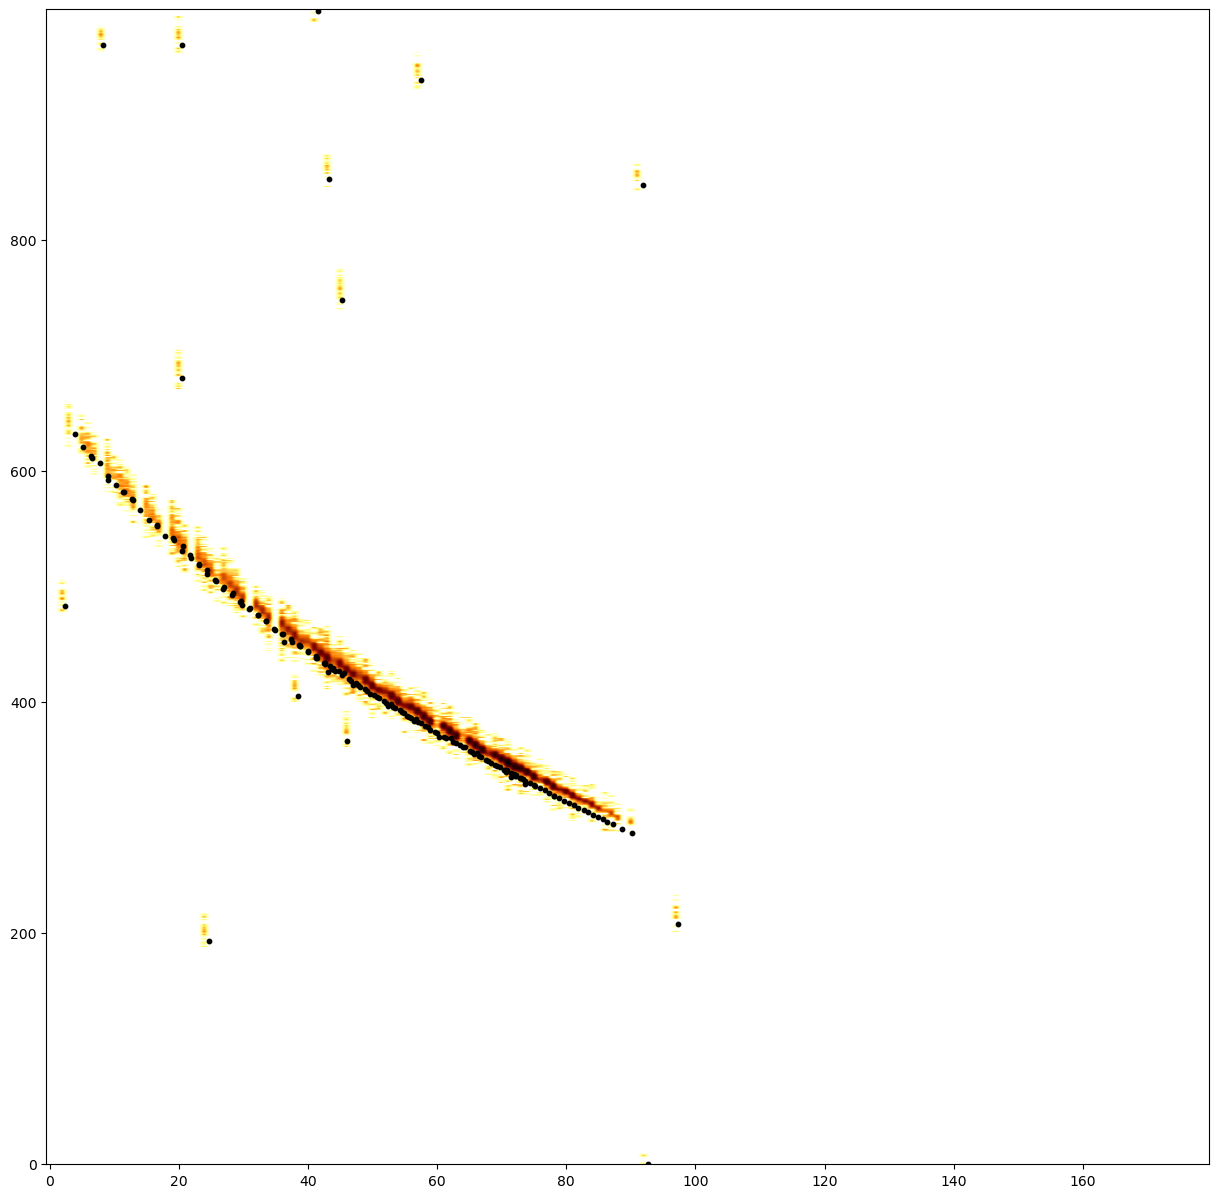

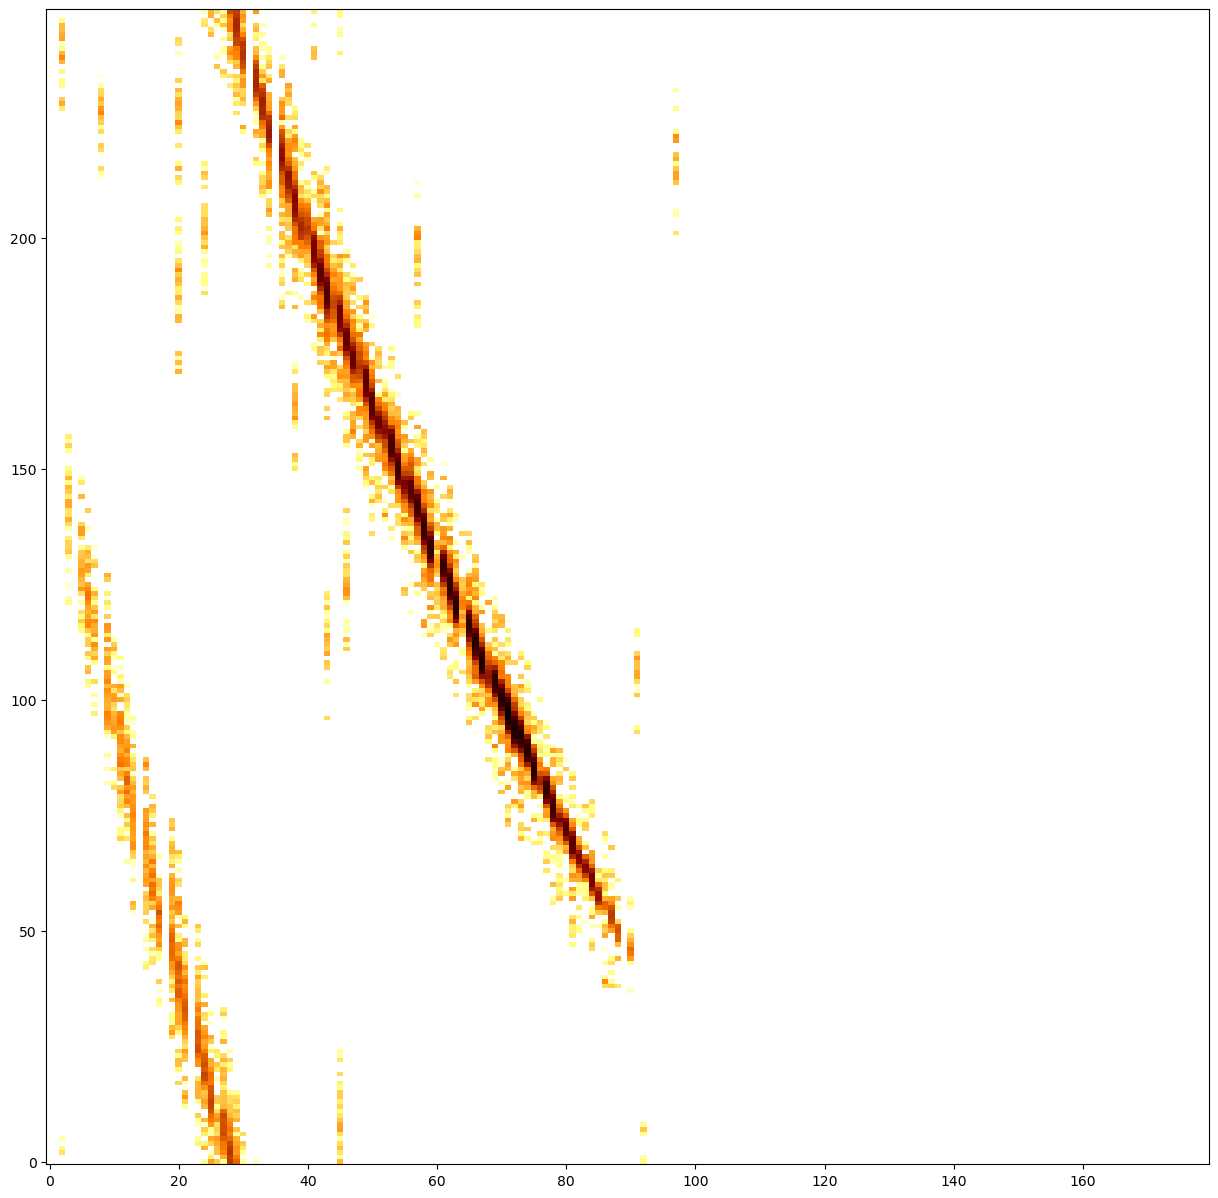

In [7]:
# ...existing code...
Event_Not_found = True

while Event_Not_found:
    N = np.random.randint(len(Dataset))
    Event = Dataset.get_event_by_index(N)
    pix_Eye_Ids = Event.get_pixel_values("EyeID")
    if (pix_Eye_Ids == 5).any() or (pix_Eye_Ids == 6).any():
        continue

    # Check the number of unique telescopes / pulse conditions
    pix_time = Event.get_pixel_values("PulseCentroid")
    pix_status = Event.get_pixel_values("Status")
    if not (pix_time[pix_status == 4] > 500).any():
        continue

    pix_chi_i = Event.get_pixel_values("Chi_i") * 180 / np.pi
    if not (pix_chi_i[pix_status == 4] > 80).any():
        continue

    T_Status = Event.get_pixel_values("Status")
    if (T_Status == 4).sum() > 35:
        Event_Not_found = False

pix_traces      = Event.get_trace_values()
pix_time        = Event.get_pixel_values("PulseCentroid")
pix_charge      = Event.get_pixel_values("Charge")
pix_chi_i       = Event.get_pixel_values("Chi_i")
pix_pulse_start = Event.get_pixel_values("PulseStart")
pix_pulse_stop  = Event.get_pixel_values("PulseStop")
pix_time_offset = Event.get_pixel_values("TimeOffset")

print(f"Pulse Start: {pix_pulse_start}")
print(f"time offset: {pix_time_offset}")

pix_main = np.zeros((181, 1500))

for i in range(len(pix_time)):
    T_pix_trace = pix_traces[i].numpy()
    T_pix_pulse_start = int(pix_pulse_start[i].item()) + int(pix_time_offset[i].item())
    T_pix_Pulse_stop = int(pix_pulse_stop[i].item())
    T_pix_Chi_i = int(pix_chi_i[i].item() / np.pi * 180)
    pix_main[
        T_pix_Chi_i, T_pix_pulse_start : T_pix_pulse_start + len(T_pix_trace)
    ] += T_pix_trace

pix_main = np.log10(np.clip(pix_main, 1, np.inf) + 1)
pix_main = pix_main[:180, 0:1000]

plt.figure(figsize=[15, 15])
plt.scatter(
    pix_chi_i.numpy() * 180 / np.pi, pix_time.numpy(), s=10, c="black", cmap="viridis"
)
plt.imshow(pix_main.T, cmap="afmhot_r", aspect="auto")  # Transpose swaps X and Y
plt.gca().invert_yaxis()
plt.show()

# Summed Main
N_bin_sum_steps = 4
pix_main_sum = pix_main.reshape(
    pix_main.shape[0], N_bin_sum_steps, pix_main.shape[1] // N_bin_sum_steps
).sum(axis=1)
plt.figure(figsize=[15, 15])
plt.imshow(pix_main_sum.T, cmap="afmhot_r", aspect="auto")
plt.gca().invert_yaxis()
plt.show()

All_chi_i shape: torch.Size([6022264])


Text(0.5, 1.0, 'Distribution of Chi_i')

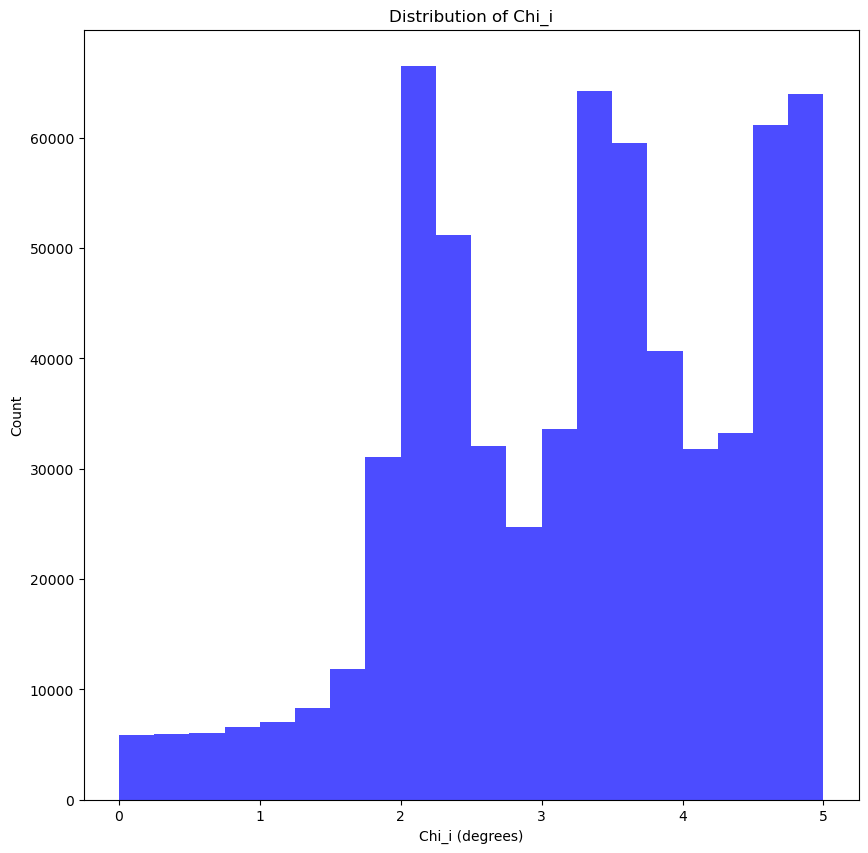

In [8]:
All_chi_i = Dataset.get_pixel_values("Chi_i")

print("All_chi_i shape:", All_chi_i.shape)

plt.figure(figsize=[10, 10])
X = All_chi_i.numpy() * 180 / np.pi
X = X[X<5]
plt.hist(X, bins=20, color="blue", alpha=0.7)
plt.xlabel("Chi_i (degrees)")
plt.ylabel("Count")
plt.title("Distribution of Chi_i")

Text(0.5, 1.0, 'Distribution of Station Total Signals')

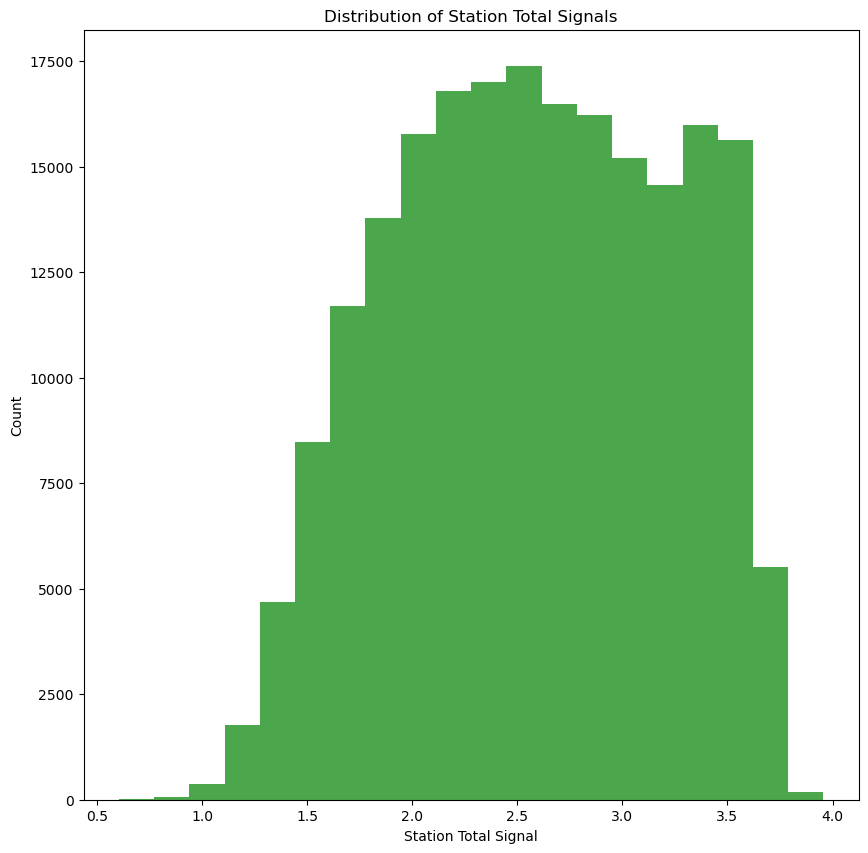

In [9]:
All_Station_signals = Dataset.get_values("Station_TotalSignal").numpy()

X = np.clip(All_Station_signals, 0, 1e5)  # Clip to a reasonable range for better visualization
X = np.log10(X + 1)  # Log-transform for better visualization

plt.figure(figsize=[10, 10])
plt.hist(X, bins=20, color="green", alpha=0.7)
plt.xlabel("Station Total Signal")
plt.ylabel("Count")
plt.title("Distribution of Station Total Signals")

Text(0.5, 1.0, 'Distribution of Station Times')

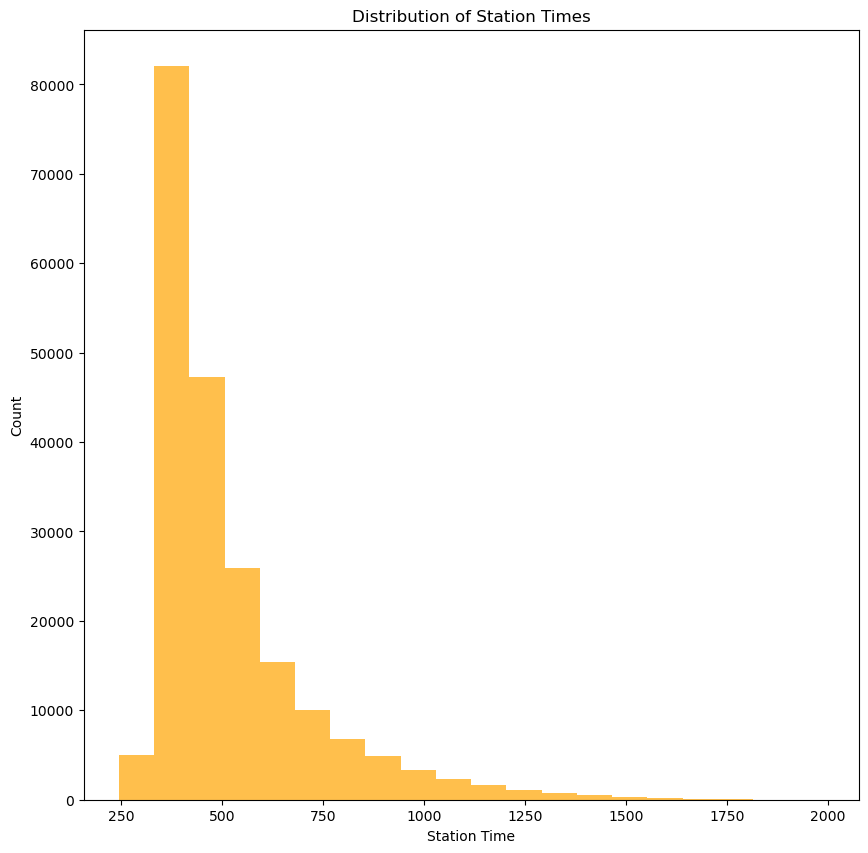

In [10]:
All_Station_Time  = Dataset.get_values("Station_Time").numpy()
plt.figure(figsize=[10, 10])
plt.hist(All_Station_Time, bins=20, color="orange", alpha=0.7)
plt.xlabel("Station Time")
plt.ylabel("Count")
plt.title("Distribution of Station Times")

In [19]:
Path = os.path.abspath("../Models/")
if Path not in sys.path:
    sys.path.append(Path)

import importlib
import FlatTimeFit_Conv2d_DataGen

importlib.reload(FlatTimeFit_Conv2d_DataGen)

Graph_FlatTimeFit = FlatTimeFit_Conv2d_DataGen.Graph_FlatTimeFit



In [20]:
Graph_Data = Graph_FlatTimeFit(Dataset,None)

In [21]:
All_Graph_Signals = []

for graph in Graph_Data:
    T_values = graph['values']
    All_Graph_Signals.append(T_values.numpy())


All_Graph_Signals = np.concatenate(All_Graph_Signals)
